In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/train.csv')
print(f'Shape: ${df.shape}')

Shape: $(891, 12)


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

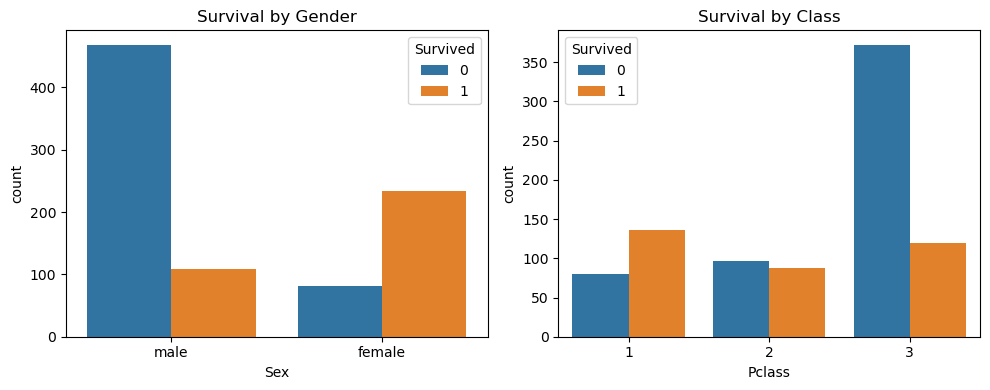

In [6]:
df["Survived"] = df["Survived"].astype(str)
plt.figure(figsize = (10,4))

plt.subplot(1,2,1)
sns.countplot(x='Sex', hue='Survived', data = df)
plt.title('Survival by Gender')

plt.subplot(1,2,2)
sns.countplot(x='Pclass',hue='Survived',data = df)
plt.title('Survival by Class')

plt.tight_layout()
plt.show()

In [7]:
df['Survived'] = df['Survived'].astype(int)
print("Survival rate by Gender:")
print(df.groupby('Sex')['Survived'].mean())

print("Survival rate by Class")
print(df.groupby('Pclass')['Survived'].mean())

Survival rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Survival rate by Class
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
(df.isnull().sum()/len(df))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [10]:
df = df.drop(columns=['Cabin'])

In [11]:
median_age= df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
# print(f"Age filled with median: {median_age}")abs



In [12]:
most_common = df['Embarked'].mode()[0]
print(most_common)
df['Embarked'] = df['Embarked'].fillna(most_common)

S


In [13]:
df['Survived'] = df['Survived'].astype(int)


In [14]:
df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)\.',expand=False)
print(df['Title'].value_counts())

df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms',   'Miss')
df['Title'] = df['Title'].replace('Mme',  'Mrs')

print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64
Title
Mr          517
Miss        185
Mrs         126
Master       40
Dr            7
Rev           6
Col           2
Major         2
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [15]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = (df['FamilySize']==1).astype(int)
print(df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(10))

   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0
8      0      2           3        0
9      1      0           2        0


In [16]:
df['Sex'] = df['Sex'].map({'male': 0, 'female' : 1})

df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})

title_mapping = {'Mr':1, 'Miss':2,'Mrs':3, 'Master':4, 'Other':5}
df['Title'] = df['Title'].map(title_mapping)
df['Title'].head(10)

0    1.0
1    3.0
2    2.0
3    3.0
4    1.0
5    1.0
6    1.0
7    4.0
8    3.0
9    3.0
Name: Title, dtype: float64

In [17]:
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])
# df = df.drop(columns= ['isAlone'])
print(df.columns.tolist())

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone']


In [18]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [19]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size= 0.2, random_state=42
)

print(f'Training size: {X_train.shape}\nTesting size: {X_test.shape}')

Training size: (712, 10)
Testing size: (179, 10)


In [20]:
# Check where NaN values are hiding
print("Missing values in X_train:")
# print(X_train.isnull().sum())

mode_title = X_train['Title'].mode()[0]
print(mode_title)
X_train['Title'] = X_train['Title'].fillna(mode_title)
print(X_train.isnull().sum())

Missing values in X_train:
1.0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Title         0
FamilySize    0
IsAlone       0
dtype: int64


In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train,y_train)



/home/professor/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [22]:
X_test.isna().sum()
X_test['Title'] = X_test['Title'].fillna(X_test['Title'].mode()[0])
X_test.isna().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Title         0
FamilySize    0
IsAlone       0
dtype: int64

In [23]:
from sklearn.metrics import accuracy_score,confusion_matrix

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Model Accuracy: {accuracy*100:.2f}%')


Model Accuracy: 80.45%


In [26]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[89 16]
 [19 55]]


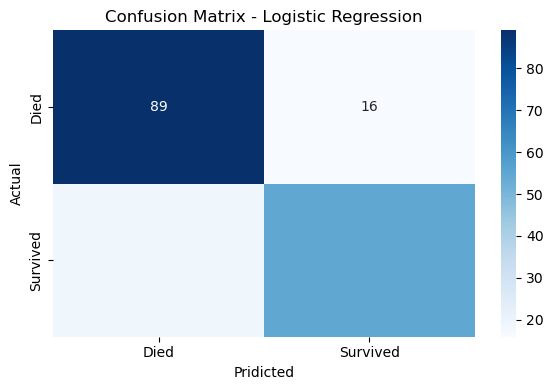

In [28]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap = 'Blues',
    xticklabels=['Died','Survived'],
    yticklabels=['Died','Survived']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Pridicted')
plt.tight_layout()
plt.show()

In [29]:
### Dicision Tree Model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=43)
dt_model.fit(X_train,y_train)

dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test,dt_pred)

print(f'Logistic Regression: {accuracy*100:.2f}%')
print(f'Decision Tree:       {dt_accuracy*100:.2f}%')





Logistic Regression: 80.45%
Decision Tree:       78.77%


In [ ]:
# Model Comparison
models = ['Logistic Regression', 'Decision Tree']
scores = [accuracy * 100, dt_accuracy * 100]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, scores, color=['#3498db', '#2ecc71'], width=0.4)

# Add accuracy labels on top of bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{score:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy %')
plt.ylim(0, 100)
plt.show()